### Овсянникова Майя группа 241, 10.03.2026

### Условие задачи

Построить модель линейной регрессии для прогнозирования оценок студентов (`Grades`) на основе их образа жизни

### Теория

Подготовила и проверила на null-ы и выбросы данные, выполнила кодирование категориальных переменных и проверила метрические переменные на мультиколлинеарность.

Подготовила учебную и тестовую выборки, обучила модель и вывела ее метрики и коэффициенты

### Документация

- `model_selection.train_test_split` Разделяет исходный датасет на две случайные выборки: обучающую (train) и тестовую (test)
- `preprocessing.StandardScaler` Стандартизирует признаки. Для каждого числового столбца он вычитает среднее значение и делит на стандартное отклонение. В результате все признаки имеют среднее = 0 и дисперсию = 1
- `linear_model.LinearRegression` Строит модель линейной регрессии

Суть модели линейной регрессии: она пытается найти линейную зависимость между признаками (**X**) и целевой переменной (**y**), то есть подбирает коэффициенты (веса) для каждого признака и свободный член так, чтобы минимизировать ошибку **MSE** (сумму квадратов разниц между фактом и предсказанием)
- `preprocessing.LabelEncoder` Преобразует категориальные метрики в числа (0, 1, ...)
- `metrics` (`mean_squared_error`, `mean_absolute_error`, `r2_score`) Вычисляют метрики качества, чтобы понять, насколько хорошо сработала модель

### Решение

#### Загрузка данных и импорт библиотек

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

df = pd.read_csv('student_lifestyle_dataset.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       2000 non-null   int64  
 1   Study_Hours_Per_Day              2000 non-null   float64
 2   Extracurricular_Hours_Per_Day    2000 non-null   float64
 3   Sleep_Hours_Per_Day              2000 non-null   float64
 4   Social_Hours_Per_Day             2000 non-null   float64
 5   Physical_Activity_Hours_Per_Day  2000 non-null   float64
 6   Stress_Level                     2000 non-null   object 
 7   Gender                           2000 non-null   object 
 8   Grades                           2000 non-null   float64
dtypes: float64(6), int64(1), object(2)
memory usage: 140.8+ KB


#### Проверка данных на пропуски и дубликаты

In [3]:
print(f"Количество пропусков:\n{df.isnull().sum()}\n")
print(f"Количество дубликатов: {df.duplicated().sum()}")

Количество пропусков:
Student_ID                         0
Study_Hours_Per_Day                0
Extracurricular_Hours_Per_Day      0
Sleep_Hours_Per_Day                0
Social_Hours_Per_Day               0
Physical_Activity_Hours_Per_Day    0
Stress_Level                       0
Gender                             0
Grades                             0
dtype: int64

Количество дубликатов: 0


У нас очень хороший датасет и их нет (иначе нужно было бы заполнить и очистить)

#### Работа с переменными

Из прошлых работ мы знаем, что в данном датасете следующие типы переменных

In [4]:
metric_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
metric_columns.remove('Student_ID')
print(f"metric_columns: {metric_columns}")

categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"categorical_columns: {categorical_columns}")

metric_columns: ['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'Grades']
categorical_columns: ['Stress_Level', 'Gender']


Целевой метрической переменной выберем `Grades`

#### Очистка выбросов

Это важно, потому что линейная регрессия минимизирует сумму квадратов ошибок **MSE**, которая к ним сильно чувствительна

##### Визуализируем выбросы

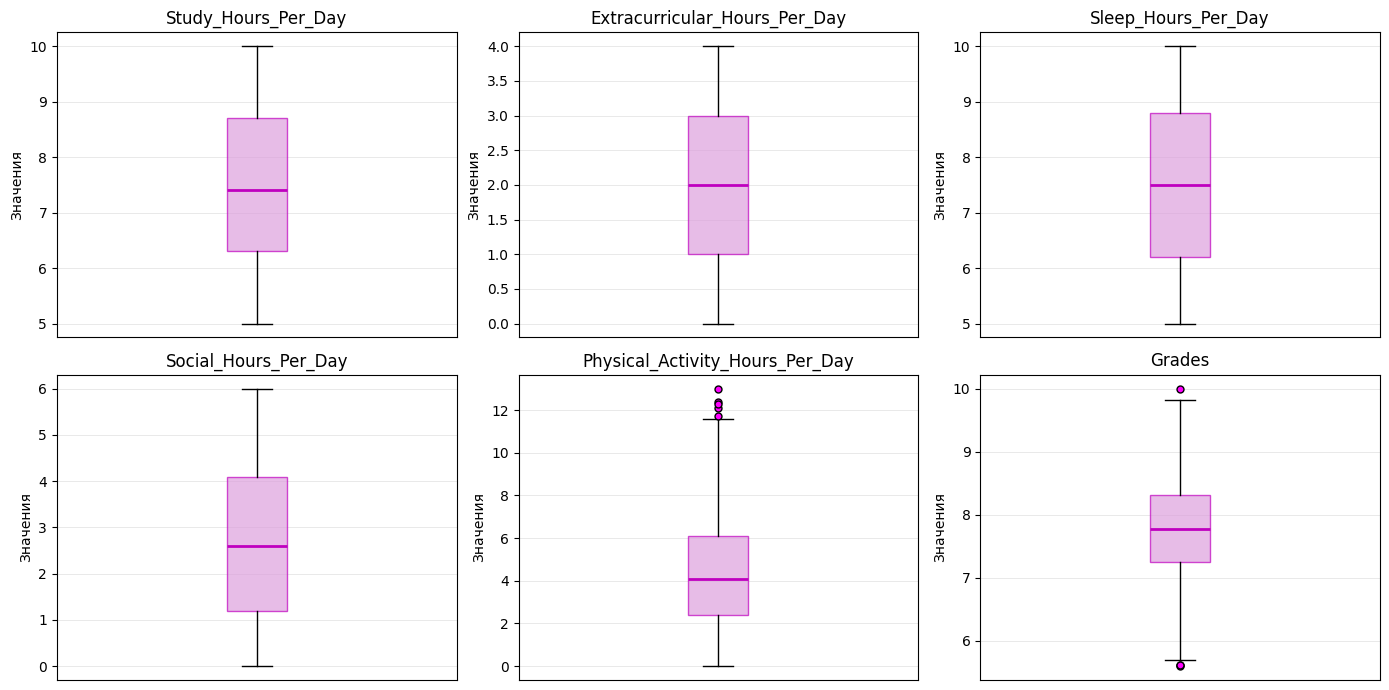

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()

for idx, col in enumerate(['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'Grades']):
    axes[idx].boxplot(df[col], patch_artist=True, boxprops=dict(facecolor='plum', color='m', alpha=0.7), medianprops=dict(color='m', linewidth=2), flierprops=dict(markerfacecolor='magenta', markersize=5))
    axes[idx].set_title(col)
    axes[idx].axes.get_xaxis().set_visible(False)
    axes[idx].grid(True, color='lightgray', linewidth=0.5, alpha=0.7)
    axes[idx].set_ylabel('Значения')

plt.tight_layout()
plt.show()

##### Очистка методом IQR

In [6]:
def outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return len(outliers), lower_bound, upper_bound

print("Выбросы до очистки")
for col in metric_columns:
    count, bl, ub = outliers(df[col])
    print(f"{col}: {count} выбросов")

print(f"\nРазмер df до очистки: {len(df)}")

for col in metric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]


print(f"Размер df после очистки: {len(df)}")

print("\nПовторная проверка: выбросы после очистки")
for col in metric_columns:
    count, lower, upper = outliers(df[col])
    print(f"{col}: {count} выбросов")

Выбросы до очистки
Study_Hours_Per_Day: 0 выбросов
Extracurricular_Hours_Per_Day: 0 выбросов
Sleep_Hours_Per_Day: 0 выбросов
Social_Hours_Per_Day: 0 выбросов
Physical_Activity_Hours_Per_Day: 5 выбросов
Grades: 4 выбросов

Размер df до очистки: 2000
Размер df после очистки: 1991

Повторная проверка: выбросы после очистки
Study_Hours_Per_Day: 0 выбросов
Extracurricular_Hours_Per_Day: 0 выбросов
Sleep_Hours_Per_Day: 0 выбросов
Social_Hours_Per_Day: 0 выбросов
Physical_Activity_Hours_Per_Day: 0 выбросов
Grades: 0 выбросов


#### Матрица корреляций

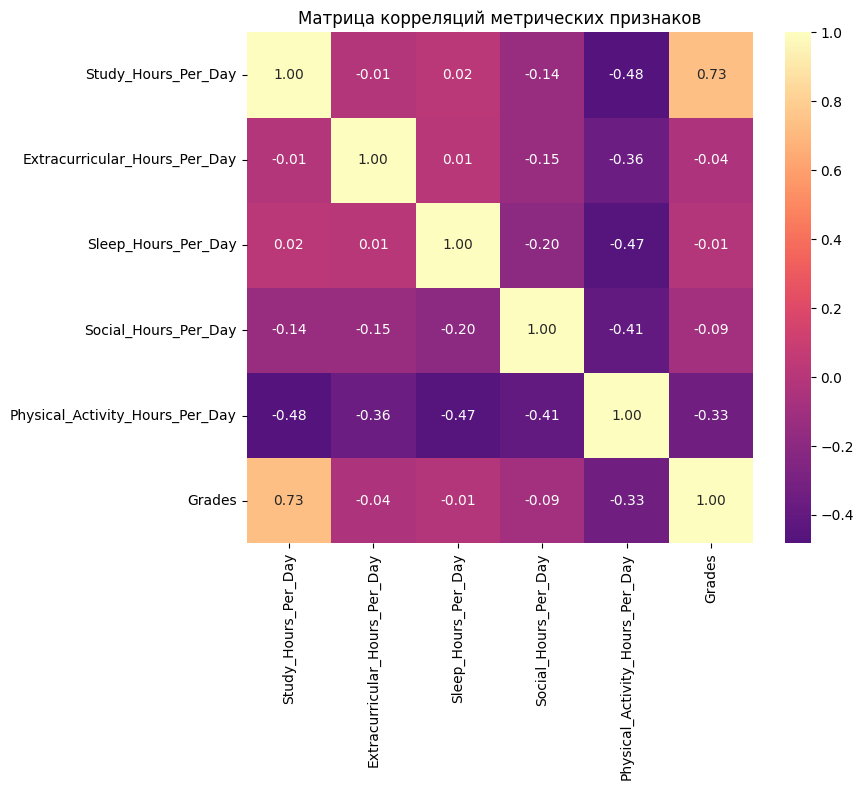

In [7]:
corr_matrix = df[metric_columns].corr()

plt.figure(figsize=(9, 8))
sns.heatmap(corr_matrix, annot=True, cmap='magma', center=0, fmt='.2f')
plt.title('Матрица корреляций метрических признаков')
plt.tight_layout()
plt.show()

Мультиколлинеарности не выявлено

#### Кодирование категориальных переменных

Кодируем категориальные переменные (для `Stress_Level_Encoded` удобнеее использовать маппинг, поскольку иначе присвоение "не по возрастанию")

In [8]:
label_encoder_gender = LabelEncoder()
df['Gender_Encoded'] = label_encoder_gender.fit_transform(df['Gender'])

stress_mapping = {'Low': 0, 'Moderate': 1, 'High': 2}
df['Stress_Level_Encoded'] = df['Stress_Level'].map(stress_mapping)

df.head(5)

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Stress_Level,Gender,Grades,Gender_Encoded,Stress_Level_Encoded
0,1,6.9,3.8,8.7,2.8,1.8,Moderate,Male,7.48,1,1
1,2,5.3,3.5,8.0,4.2,3.0,Low,Female,6.88,0,0
2,3,5.1,3.9,9.2,1.2,4.6,Low,Male,6.68,1,0
3,4,6.5,2.1,7.2,1.7,6.5,Moderate,Male,7.20,1,1
4,5,8.1,0.6,6.5,2.2,6.6,High,Male,8.78,1,2


#### Выбор признаков для модели
Выбираем числовые признаки (исключаем `Student_ID`, исходные категориальные и саму целевую переменную `Grades`)

In [9]:
feature_columns = ['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day',  'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'Gender_Encoded', 'Stress_Level_Encoded']

X = df[feature_columns]
y = df['Grades']         


Признаки **X**: `Study_Hours_Per_Day`, `Extracurricular_Hours_Per_Day`, `Sleep_Hours_Per_Day`, `Social_Hours_Per_Day`, `Physical_Activity_Hours_Per_Day`, `Gender_Encoded`, `Stress_Level_Encoded`

Целевая переменная **y**: `Grades`

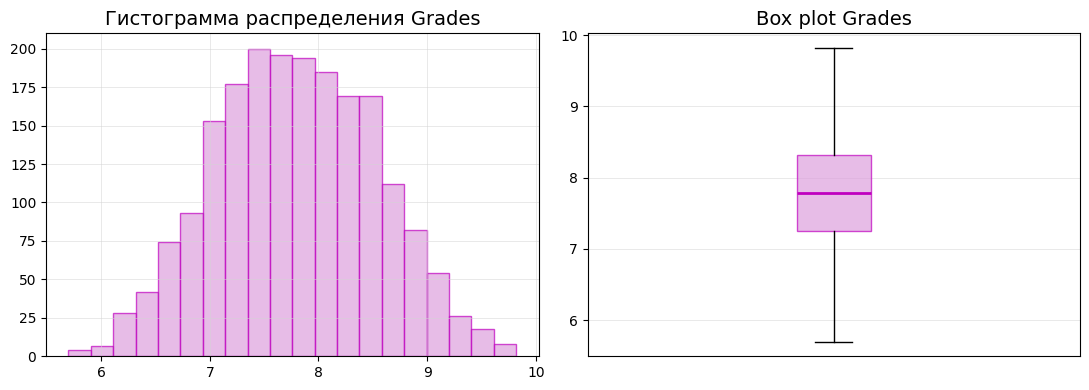

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df['Grades'], bins=20, color='plum', edgecolor='m', alpha=0.7)
axes[0].set_title('Гистограмма распределения Grades', fontsize=14)
axes[0].grid(True, color='lightgray', linewidth=0.5, alpha=0.7)

box_plot = axes[1].boxplot(df['Grades'], patch_artist=True, boxprops=dict(facecolor='plum', color='m', alpha=0.7), medianprops=dict(color='m', linewidth=2), flierprops=dict(markerfacecolor='magenta', markersize=5))

axes[1].set_title('Box plot Grades', fontsize=14)
axes[1].axes.get_xaxis().set_visible(False)
axes[1].grid(True, color='lightgray', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()

In [11]:
print(f"Grades mean: {df['Grades'].mean():.2f}")
print(f"Grades median: {df['Grades'].median():.2f}")
print(f"Grades std: {df['Grades'].std():.2f}")

Grades mean: 7.79
Grades median: 7.78
Grades std: 0.74


#### Обучение модели

##### Разделение на обучающую и тестовую выборки

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nРазмер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")


Размер обучающей выборки: 1592
Размер тестовой выборки: 399


##### Масштабирование признаков

Линейная регрессия чувствительна к масштабу признаков. Стандартизация ставит все признаки в один "вес", чтобы модель могла корректно оценить их важность (коэффициенты)

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##### Создание и обучение модели линейной регрессии

In [14]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


##### Предсказания

In [15]:
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

#### Оценка модели
- **MSE** – среднеквадратичная ошибка
- **RMSE** – корень из среднеквадратичнрй ошибки
- **MAE** – средняя абсолютная ошибка
- **R2** – коэффициент детерминации (показывает, какую долю дисперсии целевой переменной объясняет модель; чем ближе к 1, тем лучше)

##### Метрики для обучающей выборки

In [16]:
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print("Обучающая выборка")
print(f"MSE: {train_mse:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"MAE: {train_mae:.4f}")
print(f"R2: {train_r2:.4f}")

Обучающая выборка
MSE: 0.2490
RMSE: 0.4990
MAE: 0.3936
R2: 0.5386


##### Метрики для тестовой выборки

In [17]:
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Тестовая выборка")
print(f"MSE: {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE: {test_mae:.4f}")
print(f"R2: {test_r2:.4f}")

Тестовая выборка
MSE: 0.2663
RMSE: 0.5160
MAE: 0.4181
R2: 0.5376


#### Коэффициенты модели

In [18]:
coefficients = pd.DataFrame({'Признак': feature_columns,'Коэффициент': model.coef_})
coefficients = coefficients.sort_values('Коэффициент', key=abs, ascending=False)
print(coefficients)

print(f"\nСвободный член: {model.intercept_:.4f}")

                           Признак  Коэффициент
0              Study_Hours_Per_Day     0.468834
4  Physical_Activity_Hours_Per_Day    -0.121963
2              Sleep_Hours_Per_Day    -0.089230
3             Social_Hours_Per_Day    -0.083233
1    Extracurricular_Hours_Per_Day    -0.083170
5                   Gender_Encoded    -0.008521
6             Stress_Level_Encoded    -0.000831

Свободный член: 7.7832


#### Визуализация результатов

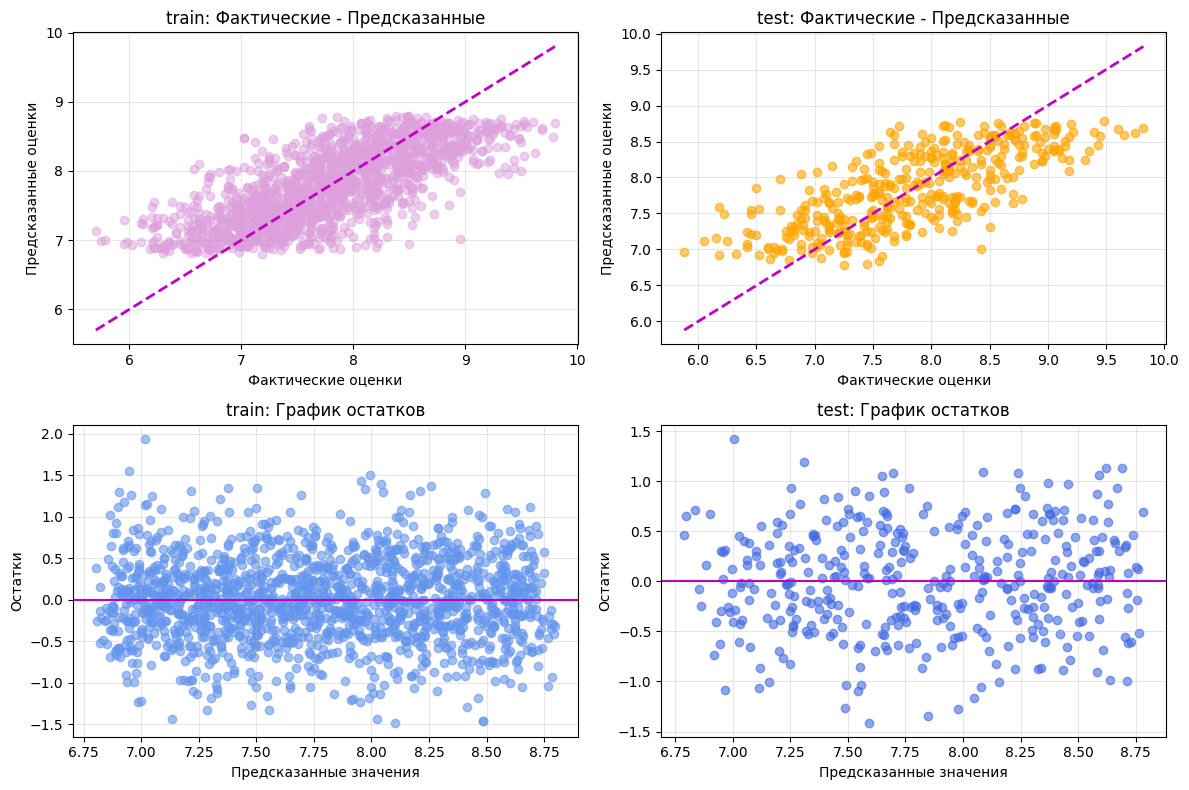

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].scatter(y_train, y_train_pred, alpha=0.5, color='plum')
axes[0, 0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], '--', lw=2, color='m')
axes[0, 0].set_xlabel('Фактические оценки')
axes[0, 0].set_ylabel('Предсказанные оценки')
axes[0, 0].set_title('train: Фактические - Предсказанные')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(y_test, y_test_pred, alpha=0.6, color='orange')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', lw=2, color='m')
axes[0, 1].set_xlabel('Фактические оценки')
axes[0, 1].set_ylabel('Предсказанные оценки')
axes[0, 1].set_title('test: Фактические - Предсказанные')
axes[0, 1].grid(True, alpha=0.3)

residuals_train = y_train - y_train_pred
axes[1, 0].scatter(y_train_pred, residuals_train, alpha=0.6, color='cornflowerblue')
axes[1, 0].axhline(y=0, color='m')
axes[1, 0].set_xlabel('Предсказанные значения')
axes[1, 0].set_ylabel('Остатки')
axes[1, 0].set_title('train: График остатков')
axes[1, 0].grid(True, alpha=0.3)

residuals_test = y_test - y_test_pred
axes[1, 1].scatter(y_test_pred, residuals_test, alpha=0.6, color='royalblue')
axes[1, 1].axhline(y=0, color='m')
axes[1, 1].set_xlabel('Предсказанные значения')
axes[1, 1].set_ylabel('Остатки')
axes[1, 1].set_title('test: График остатков')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### "Лишние" признаки?

> `Gender_Encoded    -0.008521`

> `Stress_Level_Encoded    -0.000831`

In [20]:
# без Gender и Stress Level
important_features = ['Study_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 'Extracurricular_Hours_Per_Day']

X_imp = df[important_features]
y = df['Grades']


X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(X_imp, y, test_size=0.2, random_state=42)

scaler_imp = StandardScaler()
X_train_imp_scaled = scaler_imp.fit_transform(X_train_imp)
X_test_imp_scaled = scaler_imp.transform(X_test_imp)

model_imp = LinearRegression()
model_imp.fit(X_train_imp_scaled, y_train_imp)

y_pred_imp = model_imp.predict(X_test_imp_scaled)
r2_imp = r2_score(y_test_imp, y_pred_imp)

print(f"R2 new (5 признаков): {r2_imp:.4f}")
print(f"R2 old (все 7 признаков): {test_r2:.4f}")

R2 new (5 признаков): 0.5375
R2 old (все 7 признаков): 0.5376


Вывод: изменение совсем незначительное, можно их убрать, чтобы модель стала проще и устойчивее, но по сути ничего не поменялось. Также в целом логично, что `Gender` не должен влиять на оценки


Из теории:
> Для линейной регрессии оптимально:
>
> Минимум: 1-2 ключевых признака
>
> Хорошо: 3-7 признаков
>
> Максимум: не более $n$/(10 - 20), где $n$ — число наблюдений

### Вывод

- **RMSE** `(0.516)` и **MAE** `(0.418)` показывают, что в среднем модель ошибается при предсказании оценки студента примерно на 0,42-0,52 балла. Так как диапазон `Grades` в датасете составляет примерно от 6 до 9 баллов, ошибка в 0,5 балла является вполне приемлемой, модель может довольно точно предсказать оценку

То, что **RMSE** выше, чем **MAE**, говорит о наличии небольших выбросов (**RMSE** через квадрат сильнее реагирует на них)

- **R2** `(0.538)` означает, что модель объясняет 53,8% вариации (дисперсии) оценок студентов. То есть чуть более половины того, почему один студент учится лучше другого, можно объяснить теми факторами, которые мы включили в модель
Это довольно логично, например, это могли быть такие факторы: мотивация, как-либо измеренные способности, первоначальный уровень подготовки и тд

- Наибольший положительный эффект на оценку оказывает количество часов учебы в день (`Study_Hours_Per_Day`). Остальные факторы имеют небольшое отрицательное влияние (немного странно это для переменной `Sleep_Hours_Per_Day`, но как-будто тут должна быть квадратичная зависимость (парабола))

Итого, модель имеет достаточно хороший уровень точности предсказаний